In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import quantities as pq

#from cinplaAnalysis.utils import *

%matplotlib inline

In [2]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-0.1,vmax=.1)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    im = ax.imshow(np.array(csd), origin='lower', vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))

                # Get the scientific notation text (e.g. 1e3)
        offset = cb.ax.yaxis.get_offset_text()
        
        # Move it: x > 1 pushes right of colorbar, y > 1 pushes above
        offset.set_x(5)
        offset.set_y(1.02)


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [10]:
highRes = np.load('highRes/total.npy')[1950:2000]/10 # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

lfpIdx = np.arange(101) 

totalLFPHighRes = highRes[:,lfpIdx] # LFP, 20 um spacing
totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

disk_fullDensity_idx = np.arange(202,303)
objective_disk_full_highRes = highRes[:,disk_fullDensity_idx] # oCSD, 20 um spacing



In [11]:
### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)

for l in range(objective_disk_full_lowRes.shape[1]):
    if l == 0:
        objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
    elif l == objective_disk_full_lowRes.shape[1]-1:
        objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
    else:
        objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]

for l in range(objective_disk_half_lowRes.shape[1]):
    if l == 0:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    elif l == objective_disk_half_lowRes.shape[1]-1:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    else:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]

for l in range(objective_disk_quarter_lowRes.shape[1]):
    if l == 0:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    elif l == objective_disk_quarter_lowRes.shape[1]-1:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    else:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]


In [12]:
### Calculates iCSD and standard CSD

diam = 1000E-6 * pq.m                              # [m]
sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]

# Input dictionaries for each method

step_input_high = {
    'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
    'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':20E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam,
    'sigma_top':sigma_top,
    'tol':1e-12
}

step_input_low = {
    'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':40E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam,
    'sigma_top':sigma_top,
    'tol':1e-12
}

step_input_low_half = {
    'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':80E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam,
    'sigma_top':sigma_top,
    'tol':1e-12
}

step_input_low_quarter = {
    'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':160E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam,
    'sigma_top':sigma_top,
    'tol':1e-12
}

std_input_high = {
    'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
    'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low = {
    'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low_half = {
    'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low_quarter = {
    'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}


icsd_high = StepiCSD(**step_input_high)
icsd_low = StepiCSD(**step_input_low)
icsd_low_half = StepiCSD(**step_input_low_half)
icsd_low_quarter = StepiCSD(**step_input_low_quarter)

icsd_high_std = StandardCSD(**std_input_high)
icsd_low_std = StandardCSD(**std_input_low)
icsd_low_half_std = StandardCSD(**std_input_low_half)
icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)
        

In [13]:
objective_disk_quarter_lowRes.shape

(50, 13)

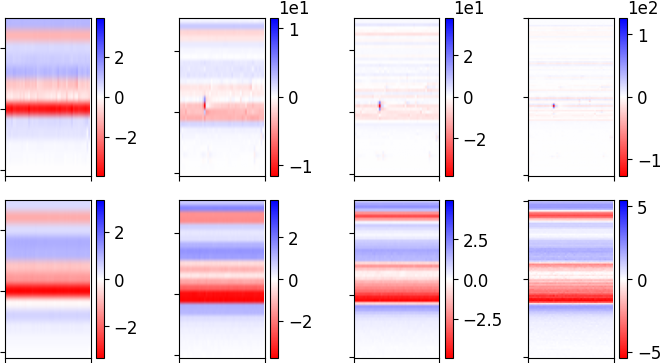

In [15]:
### Plots Figure 2a

fig, axes = plt.subplots(2,4,figsize=(7,4))

plotFig(axes[0][0],icsd_low_quarter.get_csd())
plotFig(axes[1][0],objective_disk_quarter_lowRes.T*1e-12/(np.pi*500e-6**2*160e-6))

plotFig(axes[0][1],icsd_low_half.get_csd())
plotFig(axes[1][1],objective_disk_half_lowRes.T*1e-12/(np.pi*500e-6**2*80e-6))

plotFig(axes[0][2],icsd_low.get_csd())
plotFig(axes[1][2],objective_disk_full_lowRes.T*1e-12/(np.pi*500e-6**2*40e-6))

plotFig(axes[0][3],icsd_high.get_csd())
plotFig(axes[1][3],objective_disk_full_highRes.T*1e-12/(np.pi*500e-6**2*20e-6))

plt.savefig('csds_resting.png',dpi=600)
